## ДЗ 2 — EDA

**Данные:** Breast Cancer Wisconsin (Diagnostic).  
**Kaggle:** https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data  

Каждая строка - образец ткани; признаки — числовые характеристики ядра клеток.  
**`diagnosis`:** `M` — злокачественная, `B` — доброкачественная.  
Около **569** строк.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
print (df.tail())
print (df.shape)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
564  926424         M        21.56         22.39          142.00     1479.0   
565  926682         M        20.13         28.25          131.20     1261.0   
566  926954         M        16.60         28.08          108.30      858.1   
567  927241         M        20.60         29.33          140.10     1265.0   
568   92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
564          0.11100           0.11590         0.24390              0.13890   
565          0.09780           0.10340         0.14400              0.09791   
566          0.08455           0.10230         0.09251              0.05302   
567          0.11780           0.27700         0.35140              0.15200   
568          0.05263           0.04362         0.00000              0.00000   

     ...  texture_worst  perimeter_worst  area_wor

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
df.describe(include="object")

/var/folders/04/stwy6vwx3yj78mncqpbhljsr0000gq/T/ipykernel_12475/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,diagnosis
count,569
unique,2
top,B
freq,357


In [8]:
df.describe(include="str")

,diagnosis
count,569
unique,2
top,B
freq,357


In [9]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# дубликаты по всем признакам кроме id 
dup_mask = df.duplicated(subset=df.columns.difference(["id"]), keep=False)
df[dup_mask]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32


In [14]:

df.select_dtypes(include=["number"]).lt(0).any()

id                         False
radius_mean                False
texture_mean               False
perimeter_mean             False
area_mean                  False
smoothness_mean            False
compactness_mean           False
concavity_mean             False
concave points_mean        False
symmetry_mean              False
fractal_dimension_mean     False
radius_se                  False
texture_se                 False
perimeter_se               False
area_se                    False
smoothness_se              False
compactness_se             False
concavity_se               False
concave points_se          False
symmetry_se                False
fractal_dimension_se       False
radius_worst               False
texture_worst              False
perimeter_worst            False
area_worst                 False
smoothness_worst           False
compactness_worst          False
concavity_worst            False
concave points_worst       False
symmetry_worst             False
fractal_di

In [15]:
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
df.shape
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

### Пропуски и стратегии очистки

В исходных данных после удаления `Unnamed: 32` осмысленных пропусков нет.  
Ниже на копии `df_demo` **искусственно** вводятся NaN, чтобы показать (среднее / медиана / константа) и заполнение категории **модой**.

In [16]:
df_demo = df.copy()

rng = np.random.default_rng(42)
ix_num = rng.choice(df_demo.index, size=30, replace=False)
df_demo.loc[ix_num, "radius_mean"] = np.nan

ix_cat = rng.choice(df_demo.index, size=20, replace=False)
df_demo.loc[ix_cat, "diagnosis"] = np.nan

df_demo.isnull().sum()

id                          0
diagnosis                  20
radius_mean                30
texture_mean                0
perimeter_mean              0
area_mean                   0
smoothness_mean             0
compactness_mean            0
concavity_mean              0
concave points_mean         0
symmetry_mean               0
fractal_dimension_mean      0
radius_se                   0
texture_se                  0
perimeter_se                0
area_se                     0
smoothness_se               0
compactness_se              0
concavity_se                0
concave points_se           0
symmetry_se                 0
fractal_dimension_se        0
radius_worst                0
texture_worst               0
perimeter_worst             0
area_worst                  0
smoothness_worst            0
compactness_worst           0
concavity_worst             0
concave points_worst        0
symmetry_worst              0
fractal_dimension_worst     0
dtype: int64

In [17]:
df_drop = df_demo.dropna(subset=["radius_mean", "diagnosis"])
print("Строк после dropna:", len(df_drop))

Строк после dropna: 519


**dropna** уместен, когда пропусков мало и потеря строк допустима.

**fillna** медианой (число, устойчиво к выбросам):

In [20]:
med = df_demo["radius_mean"].median()
df_med = df_demo.copy()
df_med["radius_mean"] = df_med["radius_mean"].fillna(med)

In [21]:
mn = df_demo["radius_mean"].mean()
df_mean = df_demo.copy()
df_mean["radius_mean"] = df_mean["radius_mean"].fillna(mn)

In [22]:
print("NaN в df_mean[radius_mean]:", df_mean["radius_mean"].isnull().sum())
print("NaN в df_med[radius_mean]:", df_med["radius_mean"].isnull().sum())

NaN в df_mean[radius_mean]: 0
NaN в df_med[radius_mean]: 0


In [23]:
df_const = df_demo.copy()
df_const["radius_mean"] = df_const["radius_mean"].fillna(-1.0)

In [24]:
mode_diag = df_demo["diagnosis"].mode(dropna=True)[0]
df_mode = df_demo.copy()
df_mode["diagnosis"] = df_mode["diagnosis"].fillna(mode_diag)
df_mode["diagnosis"].isnull().sum()

np.int64(0)

### Расширенная статистика

Ниже: min/max/mean/median/mode, квантили 5–95%, дисперсия, skewness, kurtosis.  
**Variance** — разброс вокруг среднего. **Skew** — перекос распределения. **Kurtosis** (в pandas — excess kurtosis) — «тяжесть» хвостов относительно нормального распределения.

In [25]:
num_cols = df.select_dtypes(include="number").columns.drop("id", errors="ignore")

stats = df[num_cols].agg(["min", "max", "mean", "median"])
stats.loc["mode"] = df[num_cols].mode().iloc[0]
stats

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
min,6.981000,9.710000,43.790000,143.500000,0.05263,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.93000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
max,28.110000,39.280000,188.500000,2501.000000,0.16340,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.04000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500
mean,14.127292,19.289649,91.969033,654.889104,0.09636,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.26919,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
median,13.370000,18.840000,86.240000,551.100000,0.09587,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.97000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
mode,12.340000,14.930000,82.610000,512.200000,0.10070,0.114700,0.000000,0.000000,0.160100,0.056670,...,12.36000,17.700000,101.700000,284.400000,0.121600,0.148600,0.000000,0.000000,0.222600,0.074270


In [26]:
qs = [0.05, 0.25, 0.5, 0.75, 0.95]
df[num_cols].quantile(qs)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0.05,9.5292,13.088,60.496,275.78,0.075042,0.04066,0.004983,0.005621,0.14150,0.053926,...,10.534,16.574,67.856,331.06,0.095734,0.071196,0.01836,0.024286,0.21270,0.062558
0.25,11.7000,16.170,75.170,420.30,0.086370,0.06492,0.029560,0.020310,0.16190,0.057700,...,13.010,21.080,84.110,515.30,0.116600,0.147200,0.11450,0.064930,0.25040,0.071460
0.50,13.3700,18.840,86.240,551.10,0.095870,0.09263,0.061540,0.033500,0.17920,0.061540,...,14.970,25.410,97.660,686.50,0.131300,0.211900,0.22670,0.099930,0.28220,0.080040
0.75,15.7800,21.800,104.100,782.70,0.105300,0.13040,0.130700,0.074000,0.19570,0.066120,...,18.790,29.720,125.400,1084.00,0.146000,0.339100,0.38290,0.161400,0.31790,0.092080
0.95,20.5760,27.150,135.820,1309.80,0.118780,0.20870,0.243020,0.125740,0.23072,0.076090,...,25.640,36.300,171.640,2009.60,0.171840,0.564120,0.68238,0.236920,0.40616,0.119520


In [27]:
df[num_cols].var()

radius_mean                    12.418920
texture_mean                   18.498909
perimeter_mean                590.440480
area_mean                  123843.554318
smoothness_mean                 0.000198
compactness_mean                0.002789
concavity_mean                  0.006355
concave points_mean             0.001506
symmetry_mean                   0.000752
fractal_dimension_mean          0.000050
radius_se                       0.076902
texture_se                      0.304316
perimeter_se                    4.087896
area_se                      2069.431583
smoothness_se                   0.000009
compactness_se                  0.000321
concavity_se                    0.000911
concave points_se               0.000038
symmetry_se                     0.000068
fractal_dimension_se            0.000007
radius_worst                   23.360224
texture_worst                  37.776483
perimeter_worst              1129.130847
area_worst                 324167.385102
smoothness_worst

In [28]:
df[num_cols].skew()

radius_mean                0.942380
texture_mean               0.650450
perimeter_mean             0.990650
area_mean                  1.645732
smoothness_mean            0.456324
compactness_mean           1.190123
concavity_mean             1.401180
concave points_mean        1.171180
symmetry_mean              0.725609
fractal_dimension_mean     1.304489
radius_se                  3.088612
texture_se                 1.646444
perimeter_se               3.443615
area_se                    5.447186
smoothness_se              2.314450
compactness_se             1.902221
concavity_se               5.110463
concave points_se          1.444678
symmetry_se                2.195133
fractal_dimension_se       3.923969
radius_worst               1.103115
texture_worst              0.498321
perimeter_worst            1.128164
area_worst                 1.859373
smoothness_worst           0.415426
compactness_worst          1.473555
concavity_worst            1.150237
concave points_worst       0

In [29]:
df[num_cols].kurtosis()  

radius_mean                 0.845522
texture_mean                0.758319
perimeter_mean              0.972214
area_mean                   3.652303
smoothness_mean             0.855975
compactness_mean            1.650130
concavity_mean              1.998638
concave points_mean         1.066556
symmetry_mean               1.287933
fractal_dimension_mean      3.005892
radius_se                  17.686726
texture_se                  5.349169
perimeter_se               21.401905
area_se                    49.209077
smoothness_se              10.469840
compactness_se              5.106252
concavity_se               48.861395
concave points_se           5.126302
symmetry_se                 7.896130
fractal_dimension_se       26.280847
radius_worst                0.944090
texture_worst               0.224302
perimeter_worst             1.070150
area_worst                  4.396395
smoothness_worst            0.517825
compactness_worst           3.039288
concavity_worst             1.615253
c

### Feature engineering

- **One-hot** для `diagnosis` (или label: два класса).  
- **Label encoding** — компактное числовое представление.  
- **Hashing** — для высокой кардинальности; здесь демонстрация на `id` (много уникальных значений), только как учебный пример.  
- **Новые признаки** — отношения и «компактность» формы.

In [30]:
# До энкодинга
df[["diagnosis"]].head()

,diagnosis
0,M
1,M
2,M
3,M
4,M


In [31]:
df_oh = pd.get_dummies(df, columns=["diagnosis"], prefix="diag", dtype=int)
df_oh.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diag_B,diag_M
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,1


In [34]:
#Label encoding:
from sklearn.preprocessing import LabelEncoder

df_le = df.copy()
le = LabelEncoder()
df_le["diagnosis_le"] = le.fit_transform(df_le["diagnosis"])
df_le[["diagnosis", "diagnosis_le"]].head()

,diagnosis,diagnosis_le
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


In [35]:
# Target encoding
# среднее по классу (0/1) — упрощённо: M=1, B=0
y_map = df["diagnosis"].map({"M": 1, "B": 0})
mean_m = y_map.mean()  # доля M в выборке
df_te = df.copy()
df_te["diagnosis_te"] = df_te["diagnosis"].map({"M": mean_m, "B": 1 - mean_m})  # грубый пример; лучше groupby по diagnosis
# корректнее:
target_mean = df.assign(y=y_map).groupby("diagnosis")["y"].mean()
df_te["diagnosis_te"] = df_te["diagnosis"].map(target_mean)
df_te[["diagnosis", "diagnosis_te"]].head()

,diagnosis,diagnosis_te
0,M,1.0
1,M,1.0
2,M,1.0
3,M,1.0
4,M,1.0


In [37]:

from category_encoders import HashingEncoder

X_id = df[["id"]].astype(str)  
he = HashingEncoder(n_components=8, cols=["id"])
X_h = he.fit_transform(X_id)
X_h.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,1
2,0,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0,0
4,0,1,0,0,0,0,0,0


In [38]:
df_fe = df.copy()
df_fe["area_perimeter_ratio"] = df_fe["area_mean"] / (df_fe["perimeter_mean"] + 1e-9)
df_fe["texture_radius_product"] = df_fe["texture_mean"] * df_fe["radius_mean"]
df_fe["compact_concavity_sum"] = df_fe["compactness_mean"] + df_fe["concavity_mean"]
df_fe[["area_perimeter_ratio", "texture_radius_product", "compact_concavity_sum"]].describe()

,area_perimeter_ratio,texture_radius_product,compact_concavity_sum
count,569.000000,569.000000,569.000000
mean,6.697413,277.409449,0.193140
std,1.626279,109.316647,0.128766
min,3.277004,93.754830,0.020975
25%,5.572539,199.162800,0.095470
50%,6.391103,246.684000,0.157220
75%,7.467647,338.805600,0.257500
max,13.381487,720.323400,0.720800


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

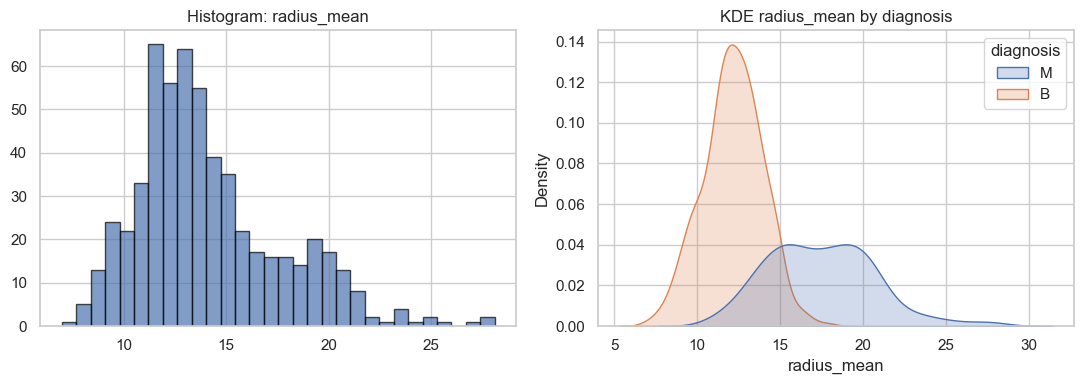

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df["radius_mean"], bins=30, edgecolor="black", alpha=0.7)
ax[0].set_title("Histogram: radius_mean")
sns.kdeplot(data=df, x="radius_mean", hue="diagnosis", ax=ax[1], fill=True)
ax[1].set_title("KDE radius_mean by diagnosis")
plt.tight_layout()
plt.show()

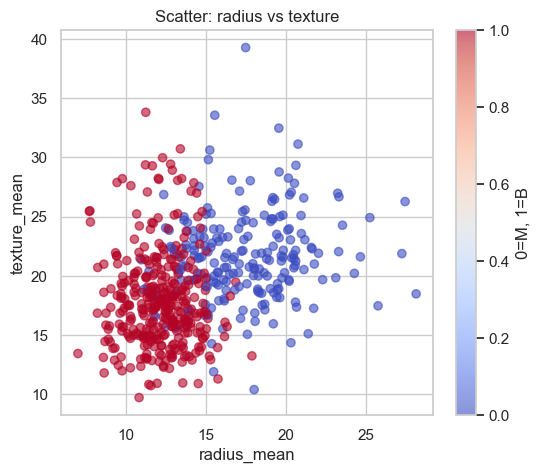

In [41]:
plt.figure(figsize=(6, 5))
plt.scatter(df["radius_mean"], df["texture_mean"], c=df["diagnosis"].map({"M": 0, "B": 1}), alpha=0.6, cmap="coolwarm")
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("Scatter: radius vs texture")
plt.colorbar(label="0=M, 1=B")
plt.show()

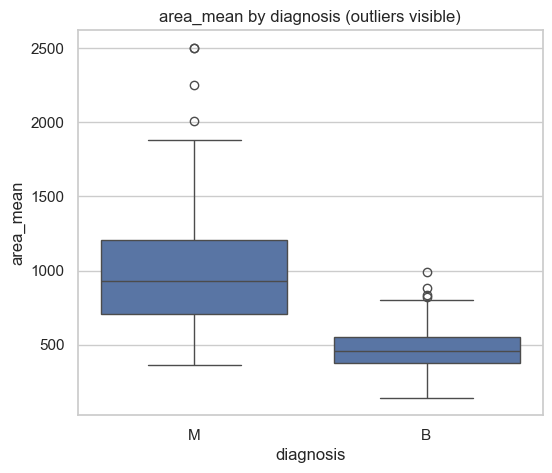

In [42]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="diagnosis", y="area_mean")
plt.title("area_mean by diagnosis (outliers visible)")
plt.show()

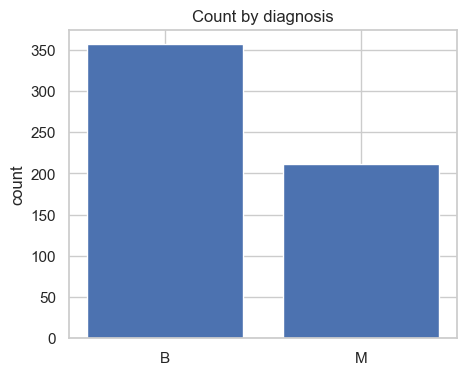

In [43]:
vc = df["diagnosis"].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(vc.index.astype(str), vc.values)
plt.title("Count by diagnosis")
plt.ylabel("count")
plt.show()

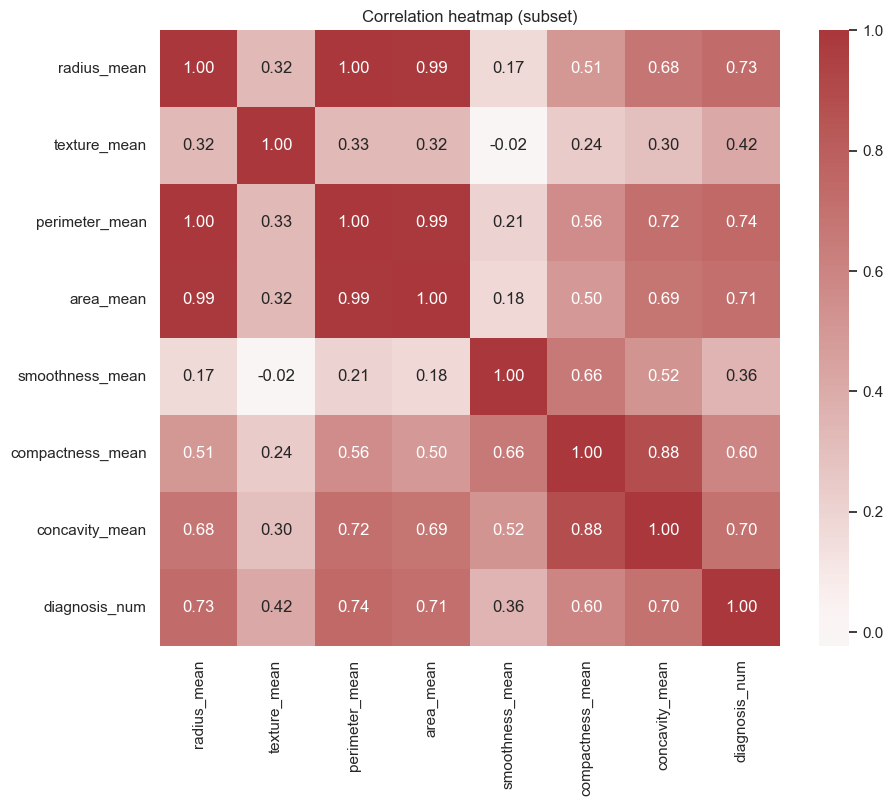

In [45]:
cols_plot = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean" 
]
df_corr = df.copy()
df_corr["diagnosis_num"] = df_corr["diagnosis"].map({"M": 1, "B": 0})
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr[cols_plot + ["diagnosis_num"]].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation heatmap (subset)")
plt.show()

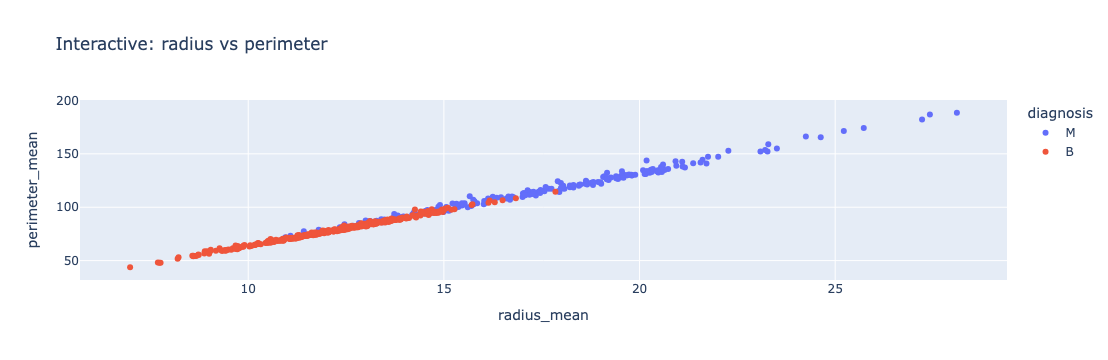

In [46]:
fig = px.scatter(
    df,
    x="radius_mean",
    y="perimeter_mean",
    color="diagnosis",
    hover_data=["area_mean", "texture_mean", "smoothness_mean"],
    title="Interactive: radius vs perimeter",
)
fig.show()

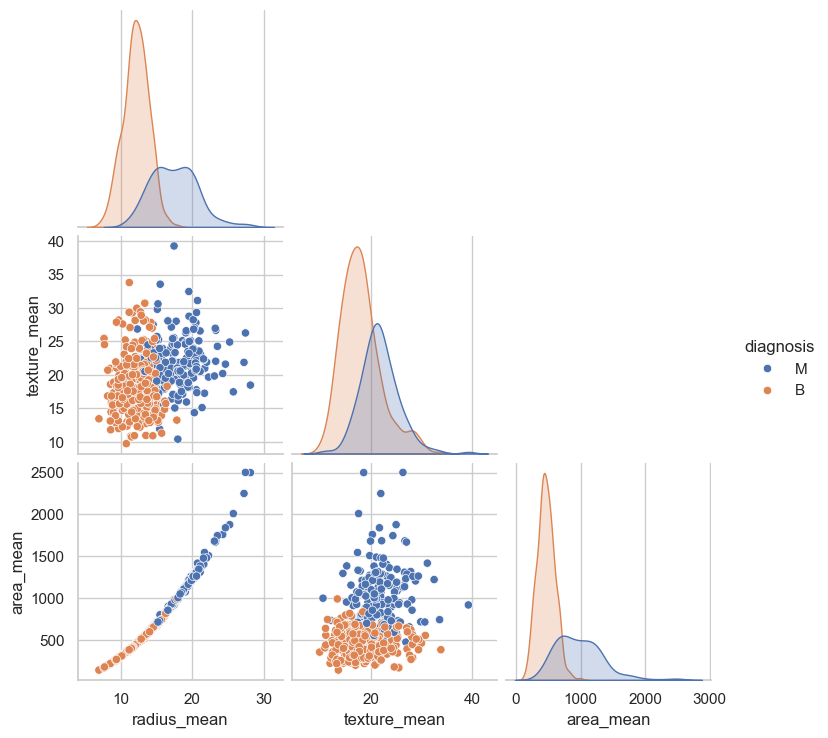

In [47]:
sns.pairplot(df, vars=["radius_mean", "texture_mean", "area_mean"], hue="diagnosis", corner=True)
plt.show()

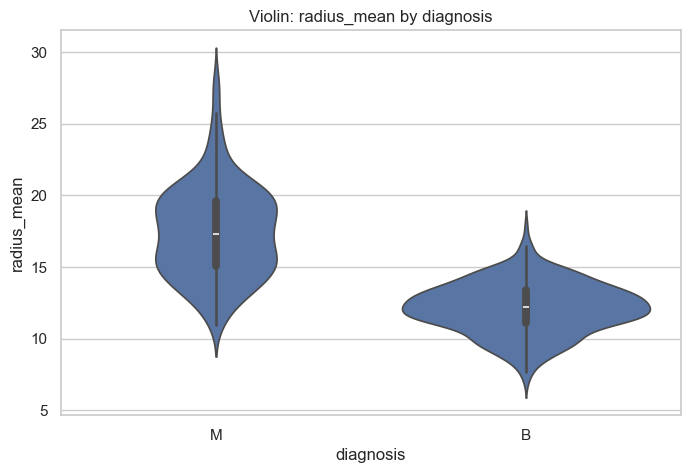

In [48]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="diagnosis", y="radius_mean")
plt.title("Violin: radius_mean by diagnosis")
plt.show()

## F) Итоговые выводы

### Что я поняла про датасет (Breast Cancer Wisconsin, Diagnostic)

- Данные — **569 образцов** ткани груди с **числовыми признаками** измерений ядра клеток и меткой **`diagnosis`**: **M** (злокачественная) / **B** (доброкачественная).
- Классы **несбалансированы**: доброкачественных (**B**) больше, чем злокачественных (**M**).
- В «сыром» CSV была **пустая служебная колонка** `Unnamed: 32` — её нужно удалять, иначе она портит статистику и пропуски.
- **Дубликатов полных строк** по смыслу признаков нет (или их мало); идентификатор **`id`** уникален.
- **Числовые признаки** сгруппированы по смыслу: средние (`*_mean`), стандартные ошибки (`*_se`), «худшие» значения (`*_worst`) — удобно сравнивать масштаб и важность групп.
- **Корреляции** между размером опухоли (`radius`, `perimeter`, `area`) сильные — признаки частично **избыточны**; для модели может понадобиться отбор или регуляризация.
- Признаки **вогнутости** и **вогнутых точек** (`concavity_*`, `concave points_*`) тяготеют к **диагнозу M** сильнее, чем «гладкость» в одиночку.
- Распределения многих признаков **асимметричны**, есть **выбросы** (особенно у площади и связанных с ней величин) — масштабирование и робастные методы уместны.
- После очистки **осмысленных пропусков в признаках нет**; блок с `fillna`/`dropna` я показывала на **искусственно повреждённой копии** для выполнения требований задания.
- **One-hot / label encoding** для двух классов даёт эквивалентные способы числового кодирования; для деревьев часто достаточно **0/1**, для линейных моделей важен масштаб признаков.
- **Визуализации** (гистограммы, KDE, scatter, box, heatmap, Plotly) согласуются: злокачественные случаи смещены в сторону **больших** размеров и **более «неровной»** геометрии ядра.

### Гипотезы и наблюдения

1. **Гипотеза:** у класса **M** в среднем выше `radius_mean`, `area_mean`, `perimeter_mean`, чем у **B**. *Проверка:* сравнение распределений и box plot по `diagnosis` — смещение медиан в сторону **M** согласуется с гипотезой.
2. **Гипотеза:** признаки **вогнутости** сильнее отделяют классы, чем **smoothness**. *Наблюдение:* по корреляциям с числовым таргетом и по графикам вклад «вогнутостей» заметнее.
3. **Наблюдение про выбросы:** крупные значения `area_*` и связанных признаков создают **длинный правый хвост** — возможны аномальные/очень крупные образцы; для модели стоит проверить влияние выбросов на метрики.
4. **Гипотеза про избыточность:** `radius`, `perimeter`, `area` почти линейно связаны — отражают **одну геометрическую** идею; при построении интерпретируемой модели можно оставить один «размерный» признак или использовать PCA/регуляризацию.

### Что бы я сделала дальше

- Формулирую задачу как **бинарную классификацию**: предсказать **`diagnosis`** (M/B).
- Разбиение на **train/test** (со стратификацией по классу), **масштабирование** числовых признаков (например, `StandardScaler` в `Pipeline`).
- Базовые модели: **логистическая регрессия**, **RandomForest**, при сравнении с лекцией по KNN — **`KNeighborsClassifier`** с подбором `k` и метрики расстояния.
- Метрики: **accuracy**, **precision/recall**, **F1**, **confusion matrix**; при дисбалансе классов — ещё **ROC-AUC**.
- Подбор гиперпараметров через **`GridSearchCV`** / **`RandomizedSearchCV`** с **кросс-валидацией**, без «подглядывания» в test.

### Про использование AI

- У **AI** брала: общий **план EDA**, примеры **кода**и как устранить определенные ошибки и установки пакетов.
- **Руками** писала код!! проверяла: запуск ячеек, **исправление** списков колонок и порядка ячеек, подгонка текста под **свои** графики и таблицы, **Restart & Run All**, сохранение ноутбука и выгрузка в **Git**.